In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))
warnings.filterwarnings("ignore")


import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_catboost_tuning, run_lgbm_tuning, run_lr_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Credit-g](https://www.openml.org/search?type=data&status=active&id=31)

In [2]:
dataset_id = 31
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
metrics_lr = bootstrap_metrics(y_test, y_pred_lr, y_prob_lr)

[I 2025-04-21 17:37:39,234] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-21 17:37:39,277] Trial 0 finished with value: 0.8095238095238095 and parameters: {'penalty': 'l1', 'C': 0.1}. Best is trial 0 with value: 0.8095238095238095.
[I 2025-04-21 17:37:39,296] Trial 1 finished with value: 0.8485714285714286 and parameters: {'penalty': 'l2', 'C': 0.1}. Best is trial 1 with value: 0.8485714285714286.
[I 2025-04-21 17:37:39,326] Trial 2 finished with value: 0.83 and parameters: {'penalty': 'l1', 'C': 1}. Best is trial 1 with value: 0.8485714285714286.
[I 2025-04-21 17:37:39,346] Trial 3 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 0.001}. Best is trial 1 with value: 0.8485714285714286.
[I 2025-04-21 17:37:39,372] Trial 4 finished with value: 0.7457142857142857 and parameters: {'penalty': 'l2', 'C': 1e-05}. Best is trial 1 with value: 0.8485714285714286.
[I 2025-04-21 17:37:39,397] Trial 5 finished with value: 0.5 and parameters: {'p

In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb  = model_cb.predict(X_test)
y_prob_cb  = model_cb.predict_proba(X_test)[:, 1]
metrics_cb = bootstrap_metrics(y_test, y_pred_cb, y_prob_cb)

[I 2025-04-21 17:37:43,008] A new study created in memory with name: catboost_optimization
[I 2025-04-21 17:37:44,220] Trial 0 finished with value: 0.822857142857143 and parameters: {'depth': 6, 'learning_rate': 0.001, 'l2_leaf_reg': 0.001}. Best is trial 0 with value: 0.822857142857143.
[I 2025-04-21 17:37:45,401] Trial 1 finished with value: 0.8252380952380952 and parameters: {'depth': 6, 'learning_rate': 0.001, 'l2_leaf_reg': 1.0}. Best is trial 1 with value: 0.8252380952380952.
[I 2025-04-21 17:37:48,231] Trial 2 finished with value: 0.8357142857142857 and parameters: {'depth': 8, 'learning_rate': 0.001, 'l2_leaf_reg': 1.0}. Best is trial 2 with value: 0.8357142857142857.
[I 2025-04-21 17:37:57,837] Trial 3 finished with value: 0.8128571428571428 and parameters: {'depth': 10, 'learning_rate': 0.1, 'l2_leaf_reg': 0.001}. Best is trial 2 with value: 0.8357142857142857.
[I 2025-04-21 17:38:00,756] Trial 4 finished with value: 0.7495238095238095 and parameters: {'depth': 8, 'learning_r

In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
y_prob_lgbm = model_lgbm.predict_proba(X_test)[:, 1]
metrics_lgbm = bootstrap_metrics(y_test, y_pred_lgbm, y_prob_lgbm)

[I 2025-04-21 17:38:40,615] A new study created in memory with name: lightgbm_optimization
[I 2025-04-21 17:38:41,715] Trial 0 finished with value: 0.8123809523809524 and parameters: {'num_leaves': 32, 'reg_alpha': 1e-08, 'reg_lambda': 1e-06, 'learning_rate': 0.1}. Best is trial 0 with value: 0.8123809523809524.
[I 2025-04-21 17:38:43,219] Trial 1 finished with value: 0.8152380952380953 and parameters: {'num_leaves': 64, 'reg_alpha': 1.0, 'reg_lambda': 1e-08, 'learning_rate': 0.01}. Best is trial 1 with value: 0.8152380952380953.
[I 2025-04-21 17:38:43,523] Trial 2 finished with value: 0.8395238095238096 and parameters: {'num_leaves': 4, 'reg_alpha': 0.01, 'reg_lambda': 10.0, 'learning_rate': 0.03}. Best is trial 2 with value: 0.8395238095238096.
[I 2025-04-21 17:38:44,005] Trial 3 finished with value: 0.8033333333333333 and parameters: {'num_leaves': 128, 'reg_alpha': 0.001, 'reg_lambda': 0.01, 'learning_rate': 0.3}. Best is trial 2 with value: 0.8395238095238096.
[I 2025-04-21 17:38:

In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


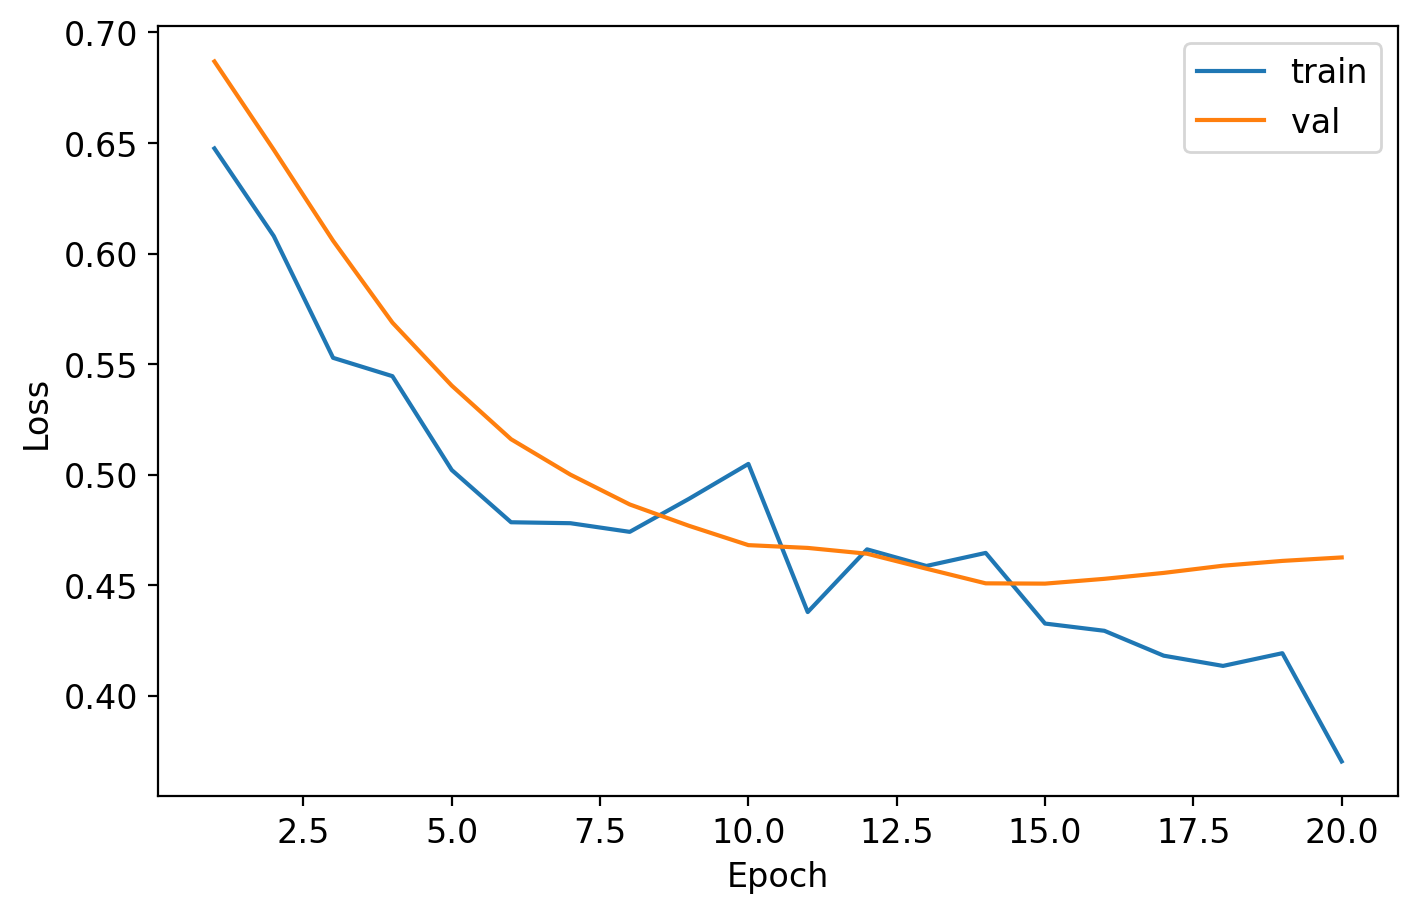

Epoch 20: train loss = 0.3703; valid loss = 0.4626


In [11]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.Adam(net.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 20, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
metrics_nn = bootstrap_metrics(y_true, y_pred, y_prob)

In [13]:
res = pd.DataFrame([{"model": "Logistic regression"} | metrics_lr, {"model": "CatBoost"} | metrics_cb, {"model": "LightGBM"} | metrics_lgbm, {"model": "TABMLP"} | metrics_nn])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,Logistic regression,0.8595±0.0378,0.8748±0.0287,0.8098±0.0392,0.8060±0.0439,0.9581±0.0232
1,CatBoost,0.8410±0.0392,0.8426±0.0322,0.7594±0.0431,0.7725±0.0465,0.9288±0.0302
2,LightGBM,0.8308±0.0425,0.8596±0.0307,0.7896±0.0406,0.8011±0.0449,0.9292±0.0298
3,TABMLP,0.8052±0.0453,0.7990±0.0383,0.7205±0.0464,0.7991±0.0506,0.8012±0.0475
